# 04.2 · Resizing and image display

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain resizing and image display using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[01 · Python for Computer Vision](../../01-python-for-computer-vision/README.md), [03 · Image Fundamentals](../../03-image-fundamentals/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

OpenCV supplies optimized building blocks for images and video. Its functions still have contracts: channel order, data type, coordinate convention and return values. Learning these contracts prevents a successful function call from silently producing the wrong image.

## 2. Intuition

Resizing interpolates a sampled grid. INTER_AREA is often useful when shrinking; nearest-neighbor preserves discrete labels in masks. Matplotlib can display images inside notebooks without a desktop window. Desktop imshow requires a GUI-enabled OpenCV build and an event loop that calls waitKey.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 4
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
I_{RGB}(y,x)=[I_{BGR}(y,x,2),I_{BGR}(y,x,1),I_{BGR}(y,x,0)]
$$

I is an image indexed by row y, column x and channel index. Reversing the three BGR channels gives RGB. BGR [10,20,200] becomes RGB [200,20,10].

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
bgr = np.array([[[10, 20, 200]]], dtype=np.uint8)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
assert rgb[0, 0].tolist() == [200, 20, 10]
print(rgb)

[[[200  20  10]]]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

OpenCV decoding produces an array, drawing edits its buffer, and encoding compresses that buffer to bytes. VideoCapture abstracts a file or device; read success is independent of the requested frame size.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def opencv_basics(lesson, seed, amount):
    image = picture(seed); drawn = image.copy()
    cv2.rectangle(drawn,(7,7),(65,55),(255,255,0),2)
    cv2.putText(drawn,'CV',(20,80),cv2.FONT_HERSHEY_SIMPLEX,.65,(255,255,255),2)
    with TemporaryDirectory() as directory:
        path = Path(directory)/'roundtrip.png'
        ok = cv2.imwrite(str(path),cv2.cvtColor(drawn,cv2.COLOR_RGB2BGR))
        bgr = cv2.imread(str(path))
        if not ok or bgr is None: raise RuntimeError('PNG encoder/decoder failed.')
        restored = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
    panels = {'Drawing primitives': drawn, 'BGR viewed as RGB (wrong)': bgr, 'PNG round trip RGB': restored}
    if lesson == 1: panels['Resized interpolation'] = cv2.resize(drawn,(48,48),interpolation=cv2.INTER_AREA)
    if lesson == 2: panels['Simulated slider threshold'] = (n.gray(image)>100*amount).astype(np.uint8)
    return Result('04 · OpenCV input, drawing and interaction contracts',panels,metrics={'lossless_equal':bool(np.array_equal(drawn,restored))},notes='The GUI and webcam adapters are separate scripts; this CPU lab uses no camera.')

{
  "lossless_equal": true
}
The GUI and webcam adapters are separate scripts; this CPU lab uses no camera.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import gray

display(Code(inspect.getsource(gray), language="python"))

def gray(image):
    """Convert RGB to float grayscale; leave 2D input as floating point."""
    values = np.asarray(image, dtype=float)
    return values @ np.array([.299, .587, .114]) if values.ndim == 3 else values

## 8. Experiment

Save the same RGB image as PNG and JPEG, reload both, and measure the maximum absolute difference after casting to signed integers.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "lossless_equal": true
  },
  "second_seed": {
    "lossless_equal": true
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

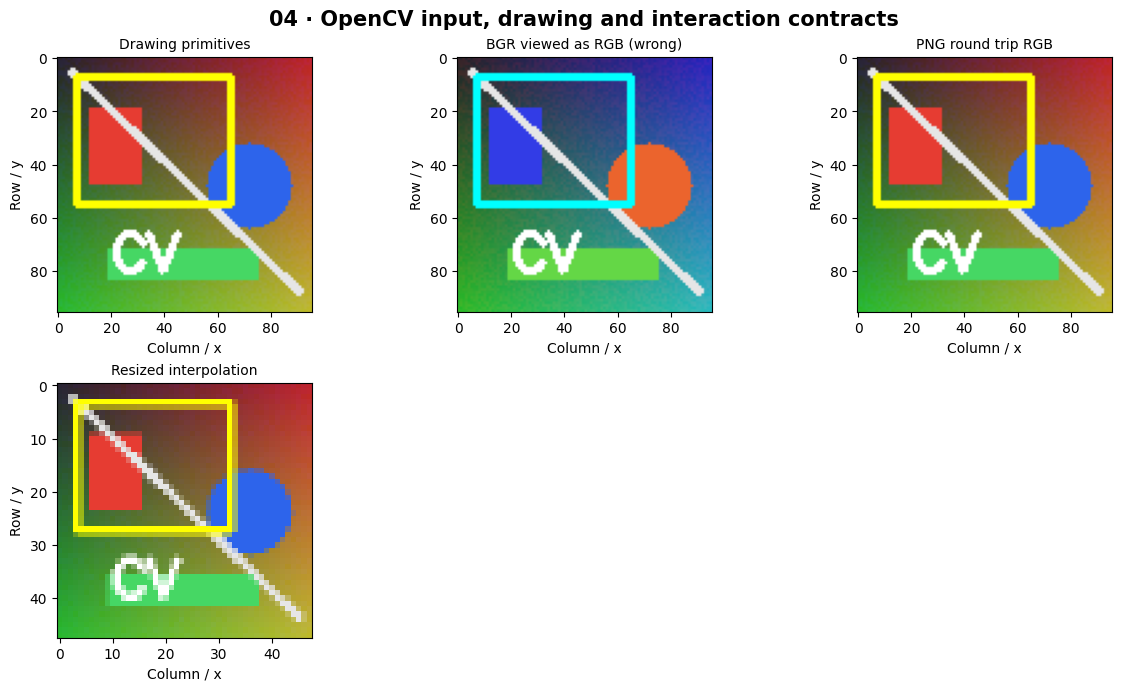

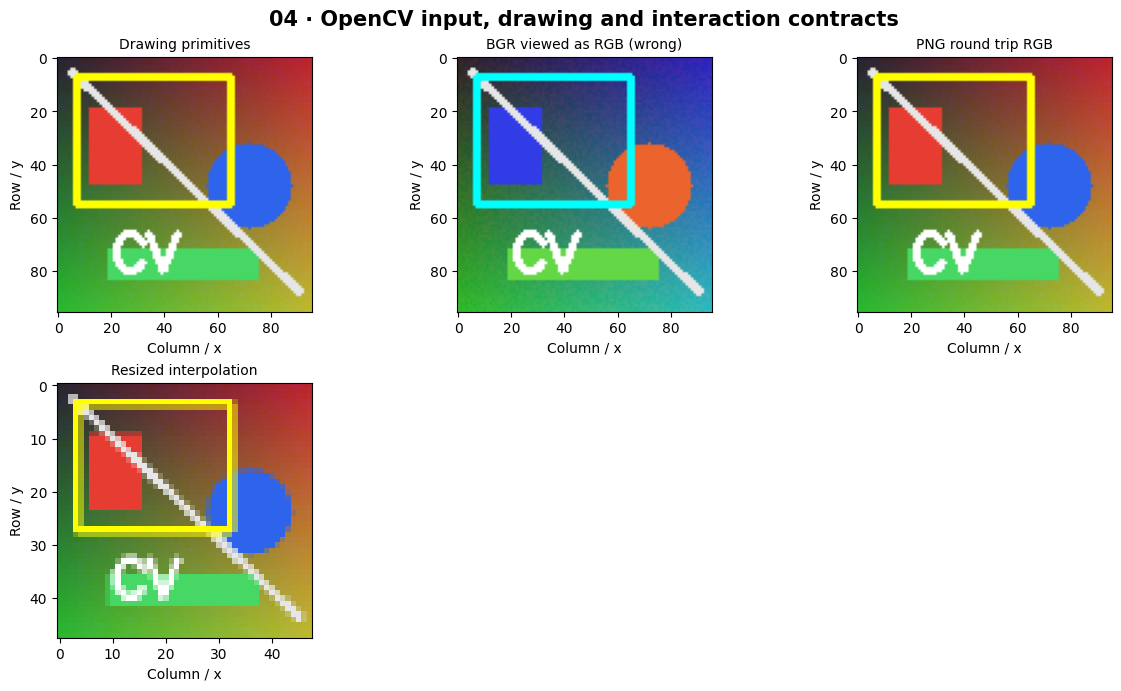

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Paint and Webcam Viewer**. Build image and webcam tools with useful failure messages. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

cv2.imread returns None on many failures. A missing camera or display is an environmental condition, not evidence that the vision algorithm is wrong.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Save the same RGB image as PNG and JPEG, reload both, and measure the maximum absolute difference after casting to signed integers.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a desktop paint application with undo, color selection and a save action that reports failures clearly.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Resizing interpolates a sampled grid. INTER_AREA is often useful when shrinking; nearest-neighbor preserves discrete labels in masks. Matplotlib can display images inside notebooks without a desktop window. Desktop imshow requires a GUI-enabled OpenCV build and an event loop that calls waitKey.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Events, camera loops and controls** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)